In [1]:
!conda install -c conda-forge cuda-nvcc cuda-cudart-dev cuda-nvrtc -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 23.11.0
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



Loading Multi‑U‑Net ...
Multi‑U‑Net loaded.

Building and loading U‑Net ...
U‑Net loaded.

Processing: 051.png


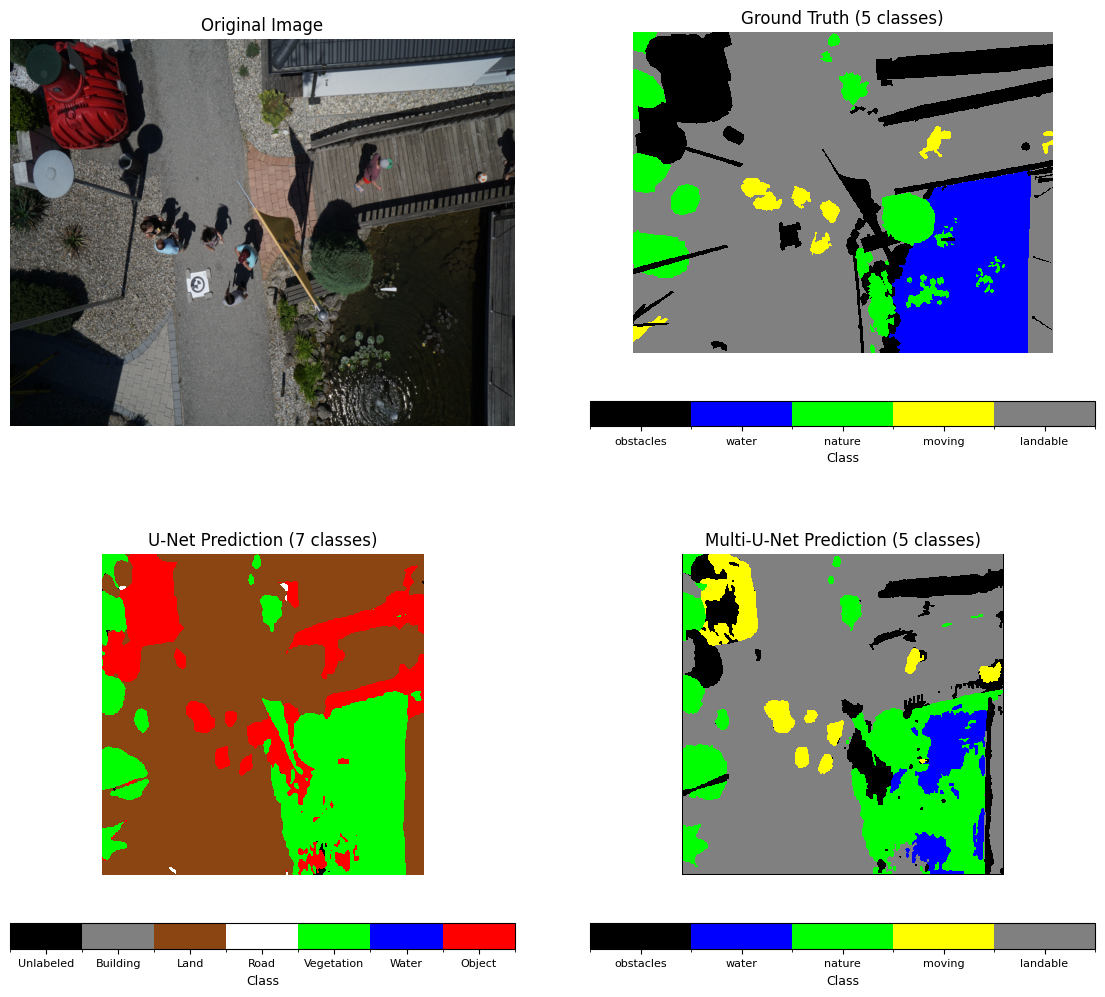

Saved: ./comparison_051.png

Processing: 078.png


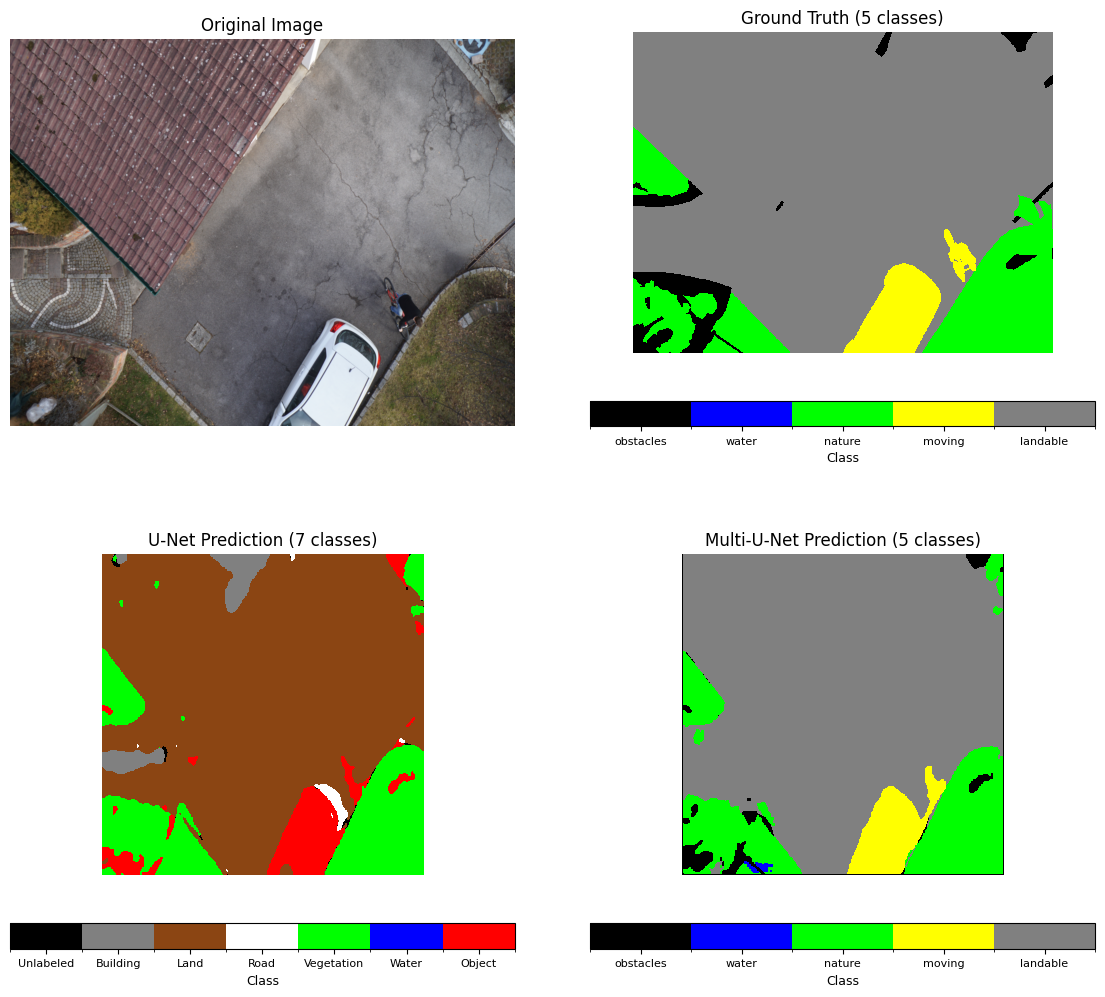

Saved: ./comparison_078.png

Processing: 173.png


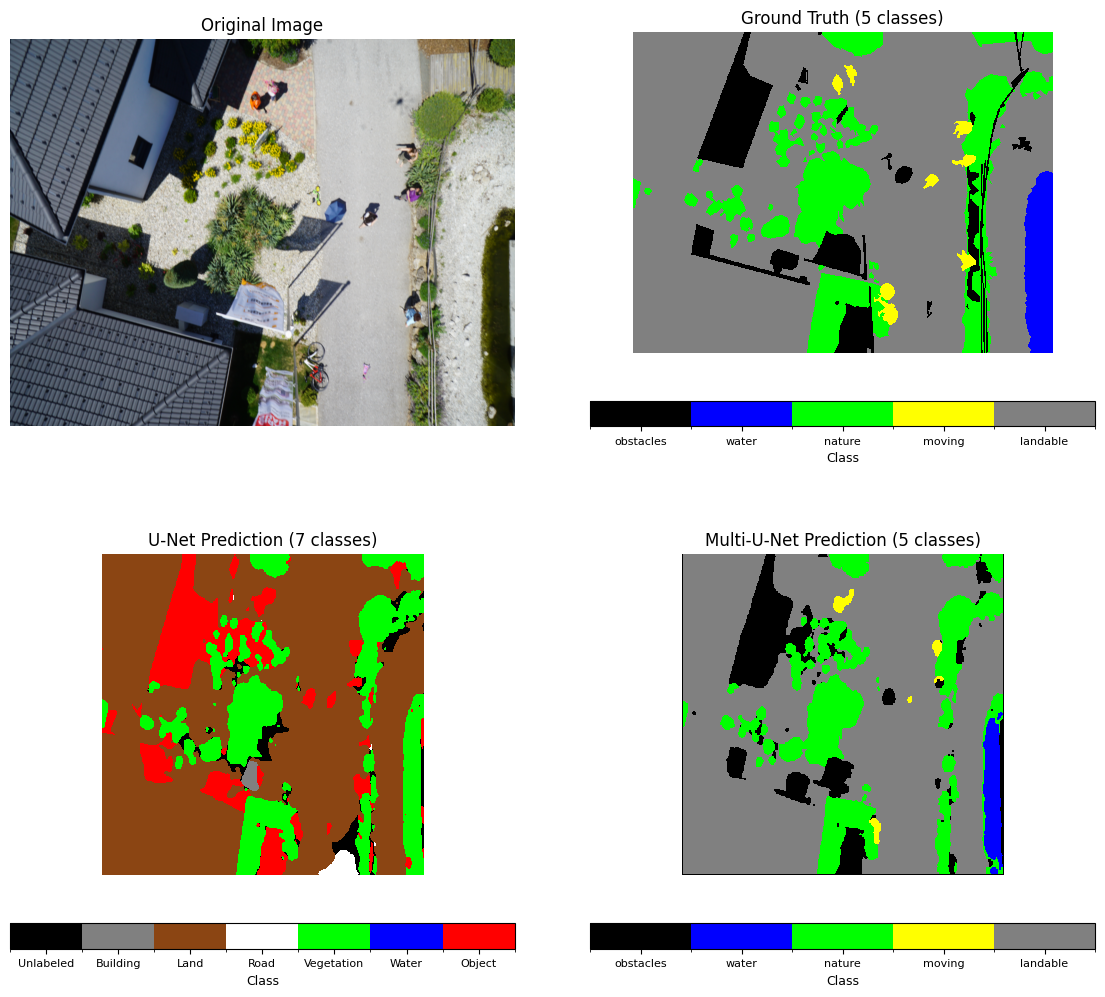

Saved: ./comparison_173.png

Processing: 228.png


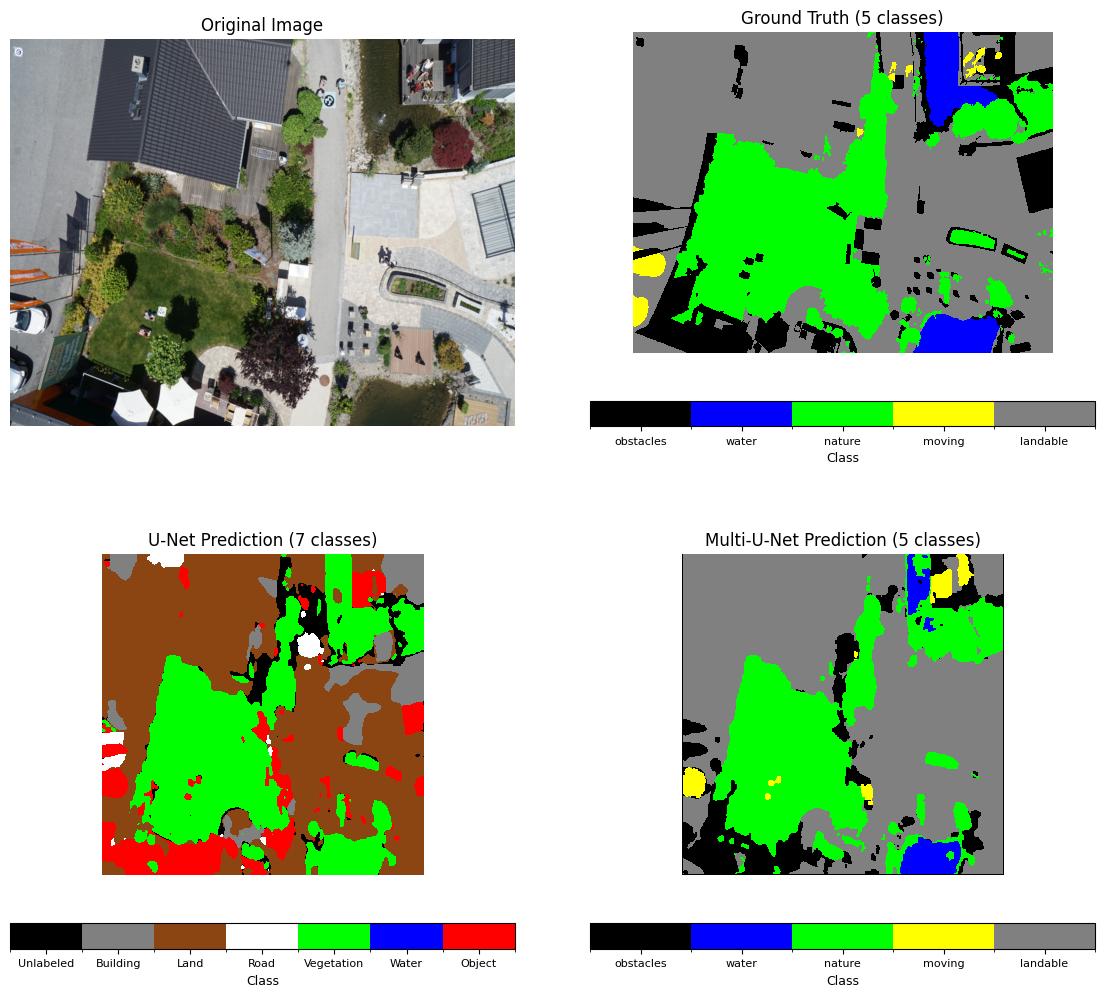

Saved: ./comparison_228.png

Processing: 596.png


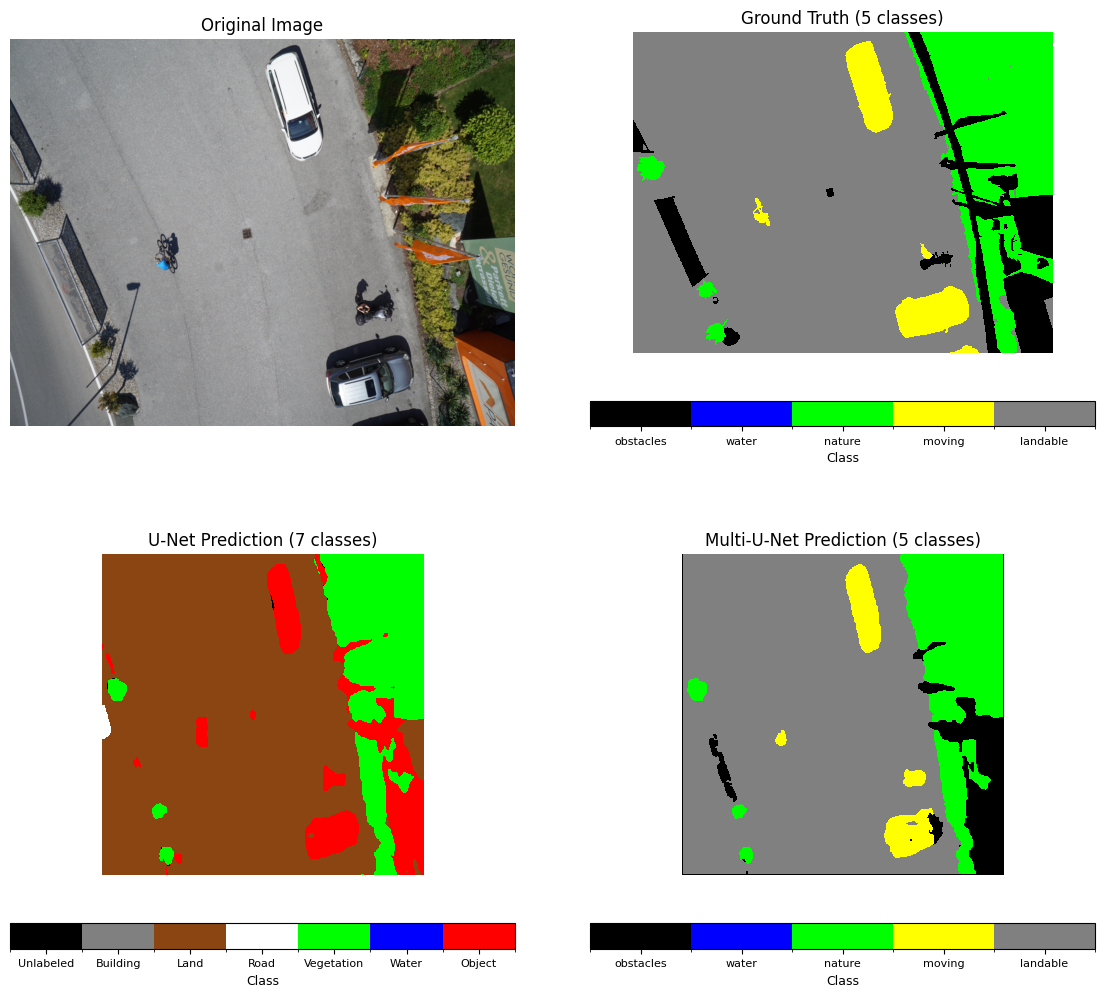

Saved: ./comparison_596.png



In [16]:
import sys
import os
sys.path.append(os.getcwd())

from src.space.ModelLoadAndWork import load_model
from src.dataset.FeatureExtraction import extract_features
from src.model.MaskTransform import multi_class_post_process

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from PIL import Image
import torch

# ---------- 配置 ----------
WEIGHTS_PATH = "./best_model.weights.h5"
IMAGE_PATH   = "./resources/dataset/drone_seg_dataset/classes_dataset/classes_dataset/original_images/"
IMAGE_LIST   = ["051.png", "078.png", "173.png", "228.png", "596.png"]
LABEL_PATH   = "./resources/dataset/drone_seg_dataset/classes_dataset/classes_dataset/label_images_semantic"
INPUT_SIZE   = (512, 512)
NUM_CLASSES_UNET  = 7
NUM_CLASSES_MULTI = 5
BEST_PERM    = [3, 0, 1, 2, 4]

# 类别名称
UNET_CLASS_NAMES   = ["Unlabeled", "Building", "Land", "Road",
                      "Vegetation", "Water", "Object"]
MULTI_CLASS_NAMES  = ['obstacles', 'water', 'nature', 'moving', 'landable']

# 自定义颜色
UNET_COLORS   = ['#000000', '#808080', '#8B4513', '#FFFFFF',
                 '#00FF00', '#0000FF', '#FF0000']
MULTI_COLORS  = ['#000000', '#0000FF', '#00FF00', '#FFFF00', '#808080']

# 创建颜色映射与离散归一化
unet_cmap  = ListedColormap(UNET_COLORS)
unet_norm  = BoundaryNorm(boundaries=np.arange(-0.5, NUM_CLASSES_UNET, 1),
                          ncolors=NUM_CLASSES_UNET)
multi_cmap = ListedColormap(MULTI_COLORS)
multi_norm = BoundaryNorm(boundaries=np.arange(-0.5, NUM_CLASSES_MULTI, 1),
                          ncolors=NUM_CLASSES_MULTI)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------- 1. 加载 Multi‑U‑Net ----------
print("Loading Multi‑U‑Net ...")
multiunet_model = load_model()
print("Multi‑U‑Net loaded.\n")

# ---------- 2. 构建并加载 U‑Net ----------
def build_unet(input_shape=(512, 512, 3), num_classes=7):
    inputs = tf.keras.layers.Input(shape=input_shape, name="unet_input")
    # Block1
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', name="en_block1_conv1")(inputs)
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', name="en_block1_conv2")(x)
    b1 = x
    x = tf.keras.layers.MaxPooling2D((2,2), strides=(2,2), name="block1_mxp")(x)
    # Block2
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', name="en_block2_conv1")(x)
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', name="en_block2_conv2")(x)
    b2 = x
    x = tf.keras.layers.MaxPooling2D((2,2), strides=(2,2), name="block2_mxp")(x)
    # Block3
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same', name="en_block3_conv1")(x)
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same', name="en_block3_conv2")(x)
    b3 = x
    x = tf.keras.layers.MaxPooling2D((2,2), strides=(2,2), name="block3_mxp")(x)
    # Block4
    x = tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same', name="en_block4_conv1")(x)
    x = tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same', name="en_block4_conv2")(x)
    b4 = x
    x = tf.keras.layers.MaxPooling2D((2,2), strides=(2,2), name="en_block4_mxp")(x)
    # Bottleneck
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', name="btn_conv1")(x)
    x = tf.keras.layers.Conv2D(1024, (3,3), activation='relu', padding='same', name="btn_conv2")(x)
    x = tf.keras.layers.UpSampling2D((2,2), interpolation='nearest', name="btn_output")(x)
    # Decoder Block1
    x = tf.keras.layers.Conv2D(1024, (3,3), activation='relu', padding='same', name="de_block1_conv1")(x)
    x = tf.keras.layers.concatenate([b4, x])
    x = tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same', name="de_block1_conv2")(x)
    x = tf.keras.layers.UpSampling2D((2,2), interpolation='nearest', name="de_block1_up")(x)
    # Decoder Block2
    x = tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same', name="de_block2_conv1")(x)
    x = tf.keras.layers.concatenate([b3, x])
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same', name="de_block2_conv2")(x)
    x = tf.keras.layers.UpSampling2D((2,2), interpolation='nearest', name="de_block2_up")(x)
    # Decoder Block3
    x = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same', name="de_block3_conv1")(x)
    x = tf.keras.layers.concatenate([b2, x])
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', name="de_block3_conv2")(x)
    x = tf.keras.layers.UpSampling2D((2,2), interpolation='nearest', name="de_block3_up")(x)
    # Decoder Block4
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same', name="de_block4_conv1")(x)
    x = tf.keras.layers.concatenate([b1, x])
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', name="de_block4_conv2")(x)
    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same', name="de_block4_conv3")(x)
    outputs = tf.keras.layers.Conv2D(num_classes, (1,1), activation='relu', padding='same', name="de_block4_conv4")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="unet")

print("Building and loading U‑Net ...")
unet_model = build_unet((*INPUT_SIZE, 3), NUM_CLASSES_UNET)
unet_model.load_weights(WEIGHTS_PATH)
print("U‑Net loaded.\n")

# ---------- 3. Multi‑U‑Net 单张推理 ----------
def multiunet_predict(model, pil_image, size=(512,512)):
    img = pil_image.convert("RGB").resize(size)
    img_np = np.array(img, dtype=np.float32)
    feat = extract_features(img_np).to(device)
    with torch.no_grad():
        out = model(feat.unsqueeze(0))
    pred = torch.argmax(out, dim=1)
    pred = multi_class_post_process(pred, BEST_PERM)
    return pred[0].cpu().numpy()                     # (H,W)

# ---------- 4. 主循环：对比可视化 ----------
for fname in IMAGE_LIST:
    print(f"Processing: {fname}")
    img_path = os.path.join(IMAGE_PATH, fname)
    lbl_path = os.path.join(LABEL_PATH, fname)

    orig_img = Image.open(img_path).convert("RGB")
    orig_size = orig_img.size

    # 缩放至模型输入尺寸
    img_512 = orig_img.resize(INPUT_SIZE)
    img_np = np.array(img_512, dtype=np.float32) / 255.0

    # 预测
    unet_pred = unet_model.predict(np.expand_dims(img_np, 0), verbose=0)
    unet_mask = np.argmax(unet_pred, axis=-1)[0]   # (512,512)

    multi_mask = multiunet_predict(multiunet_model, orig_img, INPUT_SIZE)

    # ---------- 读取真实标签（P模式） ----------
    label_img = Image.open(lbl_path).convert('P')
    label_array = np.array(label_img, dtype=np.int32)
    label_mask = np.array(Image.fromarray(label_array.astype(np.uint8))
                          .resize(orig_size, resample=Image.NEAREST))

    # ---------- 可视化（修改为 2x2 布局，紧凑间距） ----------
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))   # 改为两行两列
    plt.subplots_adjust(wspace=0.15, hspace=0.3)        # 减小水平和垂直间距

    # 1) 原始图像 (第一行第一列)
    axes[0,0].imshow(orig_img)
    axes[0,0].set_title("Original Image", fontsize=12)
    axes[0,0].axis("off")

    # 2) 真实标签 (第一行第二列)
    im1 = axes[0,1].imshow(label_mask, cmap=multi_cmap, norm=multi_norm,
                           interpolation='nearest')
    axes[0,1].set_title("Ground Truth (5 classes)", fontsize=12)
    axes[0,1].axis("off")
    cbar1 = fig.colorbar(im1, ax=axes[0,1], orientation='horizontal',
                         pad=0.12, fraction=0.08)
    cbar1.set_ticks(np.arange(NUM_CLASSES_MULTI))
    cbar1.set_ticklabels(MULTI_CLASS_NAMES, fontsize=8)
    cbar1.set_label('Class', fontsize=9)

    # 3) U‑Net 预测 (第二行第一列)
    im2 = axes[1,0].imshow(unet_mask, cmap=unet_cmap, norm=unet_norm,
                           interpolation='nearest')
    axes[1,0].set_title("U‑Net Prediction (7 classes)", fontsize=12)
    axes[1,0].axis("off")
    cbar2 = fig.colorbar(im2, ax=axes[1,0], orientation='horizontal',
                         pad=0.12, fraction=0.08)
    cbar2.set_ticks(np.arange(NUM_CLASSES_UNET))
    cbar2.set_ticklabels(UNET_CLASS_NAMES, fontsize=8)
    cbar2.set_label('Class', fontsize=9)

    # 4) Multi‑U‑Net 预测 (第二行第二列)
    im3 = axes[1,1].imshow(multi_mask, cmap=multi_cmap, norm=multi_norm,
                           interpolation='nearest')
    axes[1,1].set_title("Multi‑U‑Net Prediction (5 classes)", fontsize=12)
    axes[1,1].axis("off")
    cbar3 = fig.colorbar(im3, ax=axes[1,1], orientation='horizontal',
                         pad=0.12, fraction=0.08)
    cbar3.set_ticks(np.arange(NUM_CLASSES_MULTI))
    cbar3.set_ticklabels(MULTI_CLASS_NAMES, fontsize=8)
    cbar3.set_label('Class', fontsize=9)

    save_name = f"./comparison_{os.path.splitext(fname)[0]}.png"
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_name}\n")

In [7]:

IMAGE_PATH   = "./resources/dataset/drone_seg_dataset/classes_dataset/classes_dataset/original_images/150.png"
